# Differential expression on pseudobulk with replicates

In [7]:
here::i_am("rna/mapping/run/mnn/mapping_mnn.R")

# Load default settings
source(here::here("settings.R"))
source(here::here("utils.R"))

# Load packages
suppressPackageStartupMessages(library(scran))
suppressPackageStartupMessages(library(scater))
suppressPackageStartupMessages(library(edgeR))
suppressPackageStartupMessages(library(org.Mm.eg.db))
suppressPackageStartupMessages(library(ggrastr))



here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/10_Eomes_invitro_gut/code



In [8]:
args = list()
args$sce = file.path(io$basedir, 'results/rna/pseudobulk/celltype_genotype/SingleCellExperiment_pseudobulk_with_replicates.rds')
args$groupA = 'WT'
args$groupB = 'Eomes_KO'
args$celltypes = opts$celltypes
args$outdir = file.path(io$basedir, 'results/rna/differential')

In [9]:
meta = fread(file.path(io$basedir, 'processed/rna/metadata.txt.gz'))

In [10]:

dir.create(args$outdir, showWarnings = F)

# Define groups
opts$groups <- c(args$groupA,args$groupB)

In [11]:
sce = readRDS(args$sce)

In [12]:
# parse annotations
if (!"celltype" %in% colnames(colData(sce))) {
  sce$celltype <- colnames(sce) %>% strsplit("-") %>% map_chr(1)
}
if (!"genotype" %in% colnames(colData(sce))) {
  sce$genotype <- colnames(sce) %>% strsplit("-") %>% map_chr(2) %>% strsplit("_rep") %>% map_chr(1)
}
if (!"celltype_genotype" %in% colnames(colData(sce))) {
  sce$celltype_genotype <- sprintf("%s_%s",sce$celltype,sce$genotype)
}

In [13]:
sce_full = sce

In [14]:
gg_volcano_plot <- function(celltype_i='Allantois', top_genes=10, xlim=5, ylim=40, label_groups = NULL) {
  to.plot = DEGs[celltype == celltype_i]
  negative_hits <- to.plot[sig==TRUE & logFC<0,gene]
  positive_hits <- to.plot[sig==TRUE & logFC>0,gene]
  all <- nrow(to.plot[!is.na(sig)])
  to.plot = to.plot[,logFC_plot:=ifelse(logFC<=-xlim, -xlim, ifelse(logFC>=xlim, xlim, logFC))] %>%
               .[,log10_padj_fdr:=ifelse(-log10(padj_fdr)>=ylim, ylim, -log10(padj_fdr))]
  
  # if (is.null(xlim))
  #   xlim <- max(abs(to.plot$logFC), na.rm=T)
  # if (is.null(ylim))
  #   ylim <- max(-log10(to.plot$padj_fdr+1e-100), na.rm=T)
  
  to.plot <- to.plot[!is.na(logFC) & !is.na(padj_fdr)] %>% .[order(-abs(logFC))]
  label_genes = c(head(to.plot[sig==T & logFC<=0, gene],n=top_genes), head(to.plot[sig==T & logFC>=0, gene],n=top_genes))
  
  p <- ggplot(to.plot, aes(x=logFC_plot, y=log10_padj_fdr)) +
    labs(x="Log fold change", y=expression(paste("-log"[10],"(q.value)"))) +
    ggrastr::geom_point_rast(aes(color=sig, size=sig)) +
    # geom_hline(yintercept = -log10(opts$threshold_fdr), color="blue") +
    geom_segment(aes(x=0, xend=0, y=0, yend=ylim*0.9), color="orange", size=0.5) +
    scale_color_manual(values=c("black","red")) +
    scale_size_manual(values=c(0.5,1)) +
    scale_x_continuous(limits=c(-xlim,xlim)) +
    scale_y_continuous(limits=c(0,ylim)) +
    annotate("text", x=0, y=ylim*0.95, size=6, label=sprintf("(%d)", all)) +
    annotate("text", x=-xlim*0.9, y=ylim*0.95, size=6, label=sprintf("%d (-)",length(negative_hits))) +
    annotate("text", x=xlim*0.9, y=ylim*0.95, size=6, label=sprintf("%d (+)",length(positive_hits))) +
    ggrepel::geom_text_repel(data=to.plot[gene %in% label_genes],
                                    aes(x=logFC_plot, y=log10_padj_fdr, label=gene), max.overlaps=Inf, size=5) +
    theme_classic() +
    theme(
       axis.text = element_text(color='black'),
      # axis.title = element_text(size=rel(1.0), color='black'),
      text=element_text(size=15),
      legend.position="none"
    ) + 
    ggtitle(celltype_i)
  
  
  if (length(label_groups)>0) {
    p <- p +
      annotate("text", x=-4, y=0, size=4, label=sprintf("Up in %s",label_groups[2])) +
      annotate("text", x=4, y=0, size=4, label=sprintf("Up in %s",label_groups[1]))
  }
  
  return(rasterize(p, dpi=600))
}

In [15]:
find_DEGs = function(ct){
    print(ct)
    tmp <- sprintf("%s_%s",ct,opts$groups)
    if (any(!tmp%in%unique(sce_full$celltype_genotype))) {
      warning("...")
      out <- data.table(gene=NA, logFC=NA, padj_fdr=NA, mean_groupA=NA, mean_groupB=NA)
      #fwrite(out, args$outfile, sep="\t", na="NA", quote=F)
    } else {
      sce <- sce_full[,sce_full$celltype %in% ct]
    

        # subset genotypes
        stopifnot(opts$groups%in%sce$genotype)
        sce$genotype <- factor(sce$genotype, levels=opts$groups)
        print(table(sce$celltype_genotype))

        #########################################
        ## Calculate average expression levels ##
        #########################################

        expr.dt <- data.table(
          gene = rownames(sce),
          mean_groupA = rowMeans(logcounts(sce[,sce$genotype==args$groupA])) %>% round(2),
          mean_groupB = rowMeans(logcounts(sce[,sce$genotype==args$groupB])) %>% round(2)
        )

        #######################
        ## Feature selection ##
        #######################

        opts$min.expr <- 4 # 2**4 = 16, at least an average of 8 counts per milion for each group

        genes.to.use <- expr.dt[mean_groupA>=opts$min.expr | mean_groupB>=opts$min.expr,gene]

        ################################################
        ## Differential expression testing with edgeR ##
        ################################################

        # Convert SCE to DGEList
        sce_edger <- scran::convertTo(sce[genes.to.use,], type="edgeR")

        # Define design matrix (with intercept)
        design <- model.matrix(~sce$genotype)

        # Estimate dispersions
        sce_edger  <- estimateDisp(sce_edger,design)

        # Fit GLM
        fit <- glmQLFit(sce_edger,design)

        # Likelihood ratio test
        lrt <- glmQLFTest(fit)

        # Construct output data.frame
        out <- topTags(lrt, n=nrow(lrt))$table %>% as.data.table(keep.rownames=T) %>%
          setnames(c("gene","logFC","logCPM","LR","p.value","padj_fdr")) %>%
          .[,c("logCPM","LR","p.value"):=NULL] %>%
          .[,c("padj_fdr","logFC"):=list(signif(padj_fdr,digits=3), round(logFC,3))] %>%
          merge(expr.dt, by="gene", all.y=TRUE) %>%
          setorder(padj_fdr, na.last=T)
    }
    out = out %>% .[,celltype:=ct]
    return(out)
}

# Run analysis

In [16]:
DEGs = lapply(args$celltypes, find_DEGs)

[1] "Epiblast"

Epiblast_Eomes_KO       Epiblast_WT 
                5                 5 
[1] "Primitive_Streak"

Primitive_Streak_Eomes_KO       Primitive_Streak_WT 
                        5                         5 
[1] "Caudal_epiblast"

Caudal_epiblast_Eomes_KO       Caudal_epiblast_WT 
                       5                        5 
[1] "PGC"

PGC_Eomes_KO       PGC_WT 
           5            5 
[1] "Anterior_Primitive_Streak"

Anterior_Primitive_Streak_Eomes_KO       Anterior_Primitive_Streak_WT 
                                 5                                  5 
[1] "Notochord"


Warning message in FUN(X[[i]], ...):
“...”


[1] "Def._endoderm"


Warning message in FUN(X[[i]], ...):
“...”


[1] "Gut"


...

Warning message in FUN(X[[i]], ...):
“...”


[1] "ExE_ectoderm"


Warning message in FUN(X[[i]], ...):
“...”


[1] "Parietal_endoderm"


Warning message in FUN(X[[i]], ...):
“...”


In [20]:
DEGs = rbindlist(DEGs) %>%
    .[,sig:=ifelse(abs(logFC)>1 & padj_fdr<0.05, 'TRUE', 'FALSE')]

In [57]:
fwrite(DEGs, file.path(args$outdir, 'DEGs.txt.gz'))
fwrite(DEGs[sig==TRUE], file.path(args$outdir, 'DEGs_sig.txt.gz'))

In [58]:
fwrite(DEGs[sig==TRUE][order(celltype, logFC)], file.path(args$outdir, 'DEGs_sig.csv'))

In [59]:
for(i in unique(DEGs[sig==TRUE]$celltype)){
    p = gg_volcano_plot(i, xlim=3, ylim = 75, top_genes=15)
    ct = gsub("/", "_", i)
    pdf(sprintf('%s/results/rna/differential/DEGs_%s.pdf', io$basedir, ct), width=8, height=8)
         print(p)
    dev.off()
}

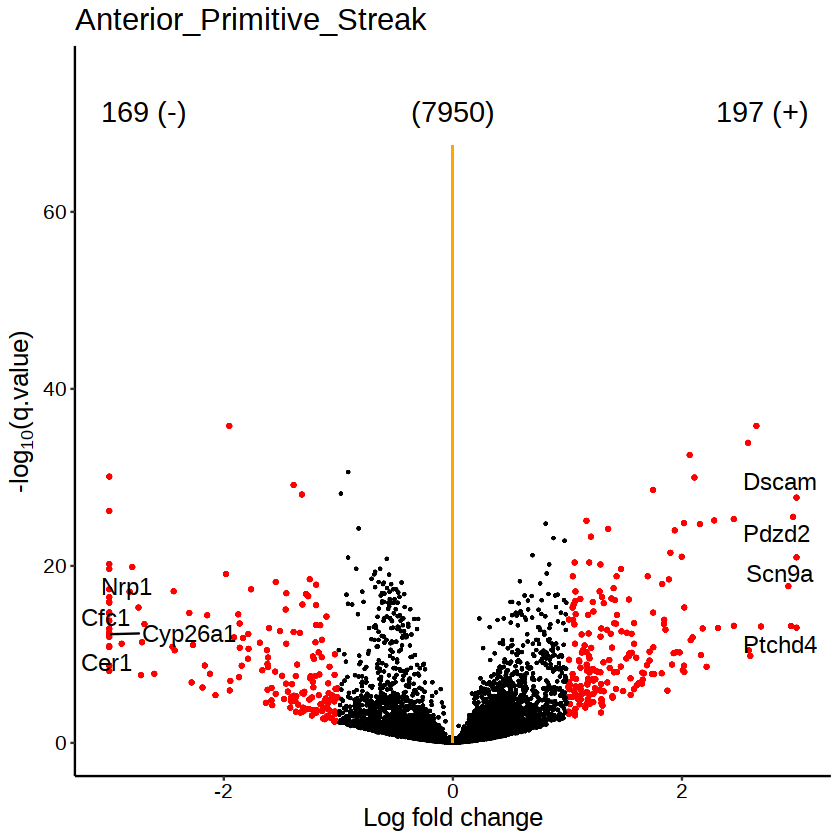

In [56]:
gg_volcano_plot('Anterior_Primitive_Streak', xlim=3, ylim = 75, top_genes=4)

In [60]:
head(DEGs[sig==TRUE])

gene,logFC,padj_fdr,mean_groupA,mean_groupB,celltype,sig
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
Mcc,1.159,6.30e-43,7.17,8.32,Epiblast,TRUE
Csrnp3,1.307,4.35e-41,5.86,7.15,Epiblast,TRUE
Klhl32,1.314,2.15e-39,5.69,6.99,Epiblast,TRUE
Hist1h2ap,-1.174,2.07e-36,7.27,6.11,Epiblast,TRUE
T,1.619,4.35e-36,4.54,6.12,Epiblast,TRUE
Ntn1,1.372,1.01e-34,5.17,6.52,Epiblast,TRUE


In [64]:
DEG_counts = DEGs[sig==TRUE] %>%
    .[,direction:=ifelse(logFC<0, 'negative', 'positive')] %>%
    .[,`:=`(N=.N, mean_logFC=mean(logFC)), by=c('gene', 'direction')] %>%
    unique(by=c('gene', 'direction')) %>%
    .[order(-N)]

In [89]:
length(unique(DEGs[sig==TRUE]$celltype))

[1] 14

png 
  2

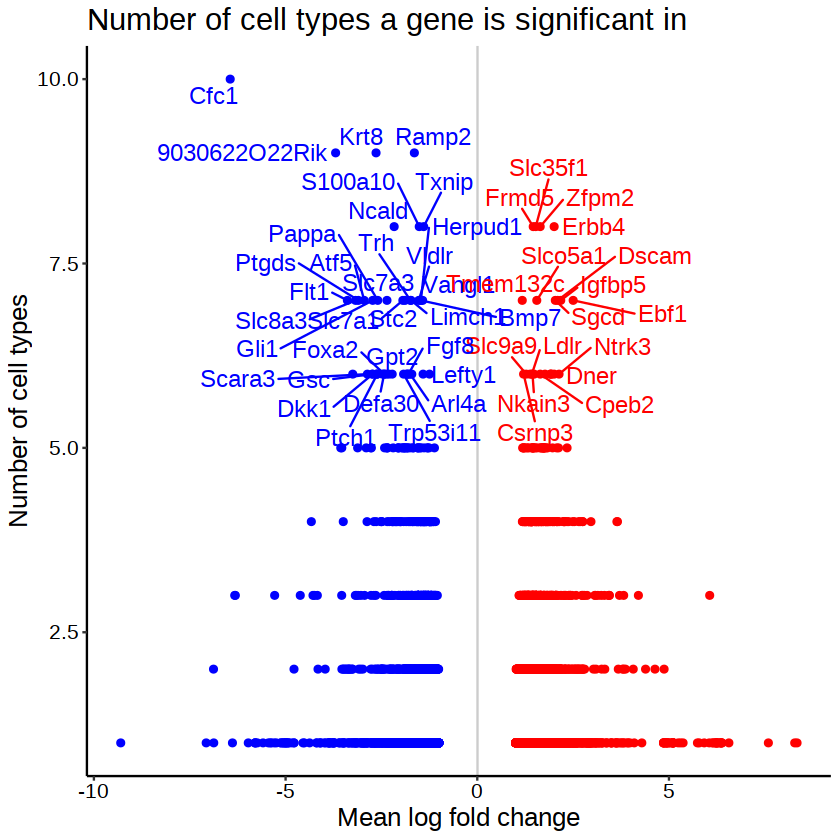

In [86]:
p = ggplot(DEG_counts, aes(x=mean_logFC, y=N, col=direction)) +
    labs(x="Mean log fold change", y='Number of cell types') +
    geom_point() + 
    geom_vline(xintercept=0, col='gray80') + 
    scale_colour_manual(values=c('negative'='blue', 'positive'='red')) +
    ggrepel::geom_text_repel(data=head(DEG_counts, 50),
                                    aes(x=mean_logFC, y=N, label=gene), max.overlaps=Inf, size=5) +
    theme_classic() +
    theme(
       axis.text = element_text(color='black'),
      # axis.title = element_text(size=rel(1.0), color='black'),
      text=element_text(size=15),
      legend.position="none"
    ) + 
    ggtitle('Number of cell types a gene is significant in')
p 
pdf(sprintf('%s/results/rna/differential/genes_across_celltypes.pdf', io$basedir), width=15, height=8)
 p
dev.off()

# Per stage!

In [ ]:
# make celltype genotype stage with replicates


##################################
## Create pseudobulk replicates ##
##################################

cell2replicate.dt <- unique(cell_metadata.dt$group) %>% map(function(i) {
  tmp <- cell_metadata.dt[group==i]
  if ((args$fraction_cells_per_replicate*nrow(tmp))<=args$min_cells) {
    ncells_per_replicate <- args$min_cells
  } else {
    ncells_per_replicate <- round(args$fraction_cells_per_replicate*nrow(tmp))
  }
  seq(1,args$nrep) %>% map(function(j) {
    tmp[sample.int(nrow(tmp),ncells_per_replicate)] %>% 
      .[,replicate:=sprintf("%s_rep%s",i,j)] %>%
      .[,c("cell","group","replicate")] %>% 
      return
  }) %>% rbindlist %>% return
}) %>% rbindlist

stats.dt <- cell2replicate.dt[,.(ncells=.N),c("group","replicate")]
print(stats.dt)

##############################
## Load RNA expression data ##
##############################

sce <- load_SingleCellExperiment(args$sce, cells=cell2replicate.dt$cell)
sce$group_by <- cell2replicate.dt$replicate

################
## Pseudobulk ##
################

sce_pseudobulk <- pseudobulk_sce_fn(
  x = sce,
  assay = "counts",
  by = "group_by",
  fun = "sum",
  scale = FALSE
)

assayNames(sce_pseudobulk) <- "counts"

###################
## Normalisation ##
###################

# log cpm
logcounts(sce_pseudobulk) <- log2(1e6*(sweep(counts(sce_pseudobulk),2,colSums(counts(sce_pseudobulk)),"/"))+1)

In [ ]:
# run DEG analysis per stage

# DEGs between celltypes rather than Eomes KO vs WT

In [9]:
args$sce = file.path(io$basedir, 'results/rna/pseudobulk/celltype/SingleCellExperiment_pseudobulk_with_replicates.rds')
sce = readRDS(args$sce)
# parse annotations
if (!"celltype" %in% colnames(colData(sce))) {
  sce$celltype <- colnames(sce) %>% strsplit("-") %>% map_chr(1)
}
sce_full = sce

In [49]:
DEGs = lapply(args$celltypes, function(ct){
    message(ct)
        args$groupA = ct
        args$groupB = setdiff(args$celltypes,ct)
    if(any(ct%in%unique(sce$celltype))==FALSE) {
      message(paste0(ct, ' skipped'))
      out <- data.table(gene=NA, logFC=NA, padj_fdr=NA, mean_groupA=NA, mean_groupB=NA)
      #fwrite(out, args$outfile, sep="\t", na="NA", quote=F)
    } else {
        #########################################
        ## Calculate average expression levels ##
        #########################################

        expr.dt <- data.table(
          gene = rownames(sce),
          mean_groupA = rowMeans(logcounts(sce[,sce$celltype==args$groupA])) %>% round(2),
          mean_groupB = rowMeans(logcounts(sce[,sce$celltype%in%args$groupB])) %>% round(2)
        )

        #######################
        ## Feature selection ##
        #######################

        opts$min.expr <- 4 # 2**4 = 16, at least an average of 8 counts per milion for each group

        genes.to.use <- expr.dt[mean_groupA>=opts$min.expr | mean_groupB>=opts$min.expr,gene]

        ################################################
        ## Differential expression testing with edgeR ##
        ################################################

        # Convert SCE to DGEList
        sce_edger <- scran::convertTo(sce[genes.to.use,], type="edgeR")
        sce_edger$design = ifelse(sce_edger$celltype==ct, 'group', 'bg')
        sce_edger$design = ifelse(sce_edger$samples$celltype==ct, 'group', 'bg')
    
        # Define design matrix (with intercept)
        design <- model.matrix(~sce_edger$design)

        # Estimate dispersions
        sce_edger  <- estimateDisp(sce_edger,design)

        # Fit GLM
        fit <- glmQLFit(sce_edger,design)

        # Likelihood ratio test
        lrt <- glmQLFTest(fit)

        # Construct output data.frame
        out <- topTags(lrt, n=nrow(lrt))$table %>% as.data.table(keep.rownames=T) %>%
          setnames(c("gene","logFC","logCPM","LR","p.value","padj_fdr")) %>%
          .[,c("logCPM","LR","p.value"):=NULL] %>%
          .[,c("padj_fdr","logFC"):=list(signif(padj_fdr,digits=3), round(logFC,3))] %>%
          merge(expr.dt, by="gene", all.y=TRUE) %>%
          setorder(padj_fdr, na.last=T)
    }
    out = out %>% .[,celltype:=ct]
    return(out)
}) %>% rbindlist(.)

Epiblast

Primitive_Streak

Caudal_epiblast

PGC

Anterior_Primitive_Streak

Notochord

Warning message in FUN(X[[i]], ...):
“Notochord skipped”
Def._endoderm

Gut

Nascent_mesoderm

Mixed_mesoderm

Intermediate_mesoderm

Caudal_Mesoderm

Warning message in FUN(X[[i]], ...):
“Caudal_Mesoderm skipped”
Paraxial_mesoderm

Somitic_mesoderm

Pharyngeal_mesoderm

Cardiomyocytes

Warning message in FUN(X[[i]], ...):
“Cardiomyocytes skipped”
Allantois

ExE_mesoderm

Mesenchyme

Haematoendothelial_progenitors

Endothelium

Blood_progenitors_1

Blood_progenitors_2

Erythroid1

Erythroid2

Warning message in FUN(X[[i]], ...):
“Erythroid2 skipped”
Erythroid3

Warning message in FUN(X[[i]], ...):
“Erythroid3 skipped”
NMP

Warning message in FUN(X[[i]], ...):
“NMP skipped”
Rostral_neurectoderm

Caudal_neurectoderm

Warning message in FUN(X[[i]], ...):
“Caudal_neurectoderm skipped”
Neural_crest

Warning message in FUN(X[[i]], ...):
“Neural_crest skipped”
Forebrain_Midbrain_Hindbrain

Spinal_cord

War

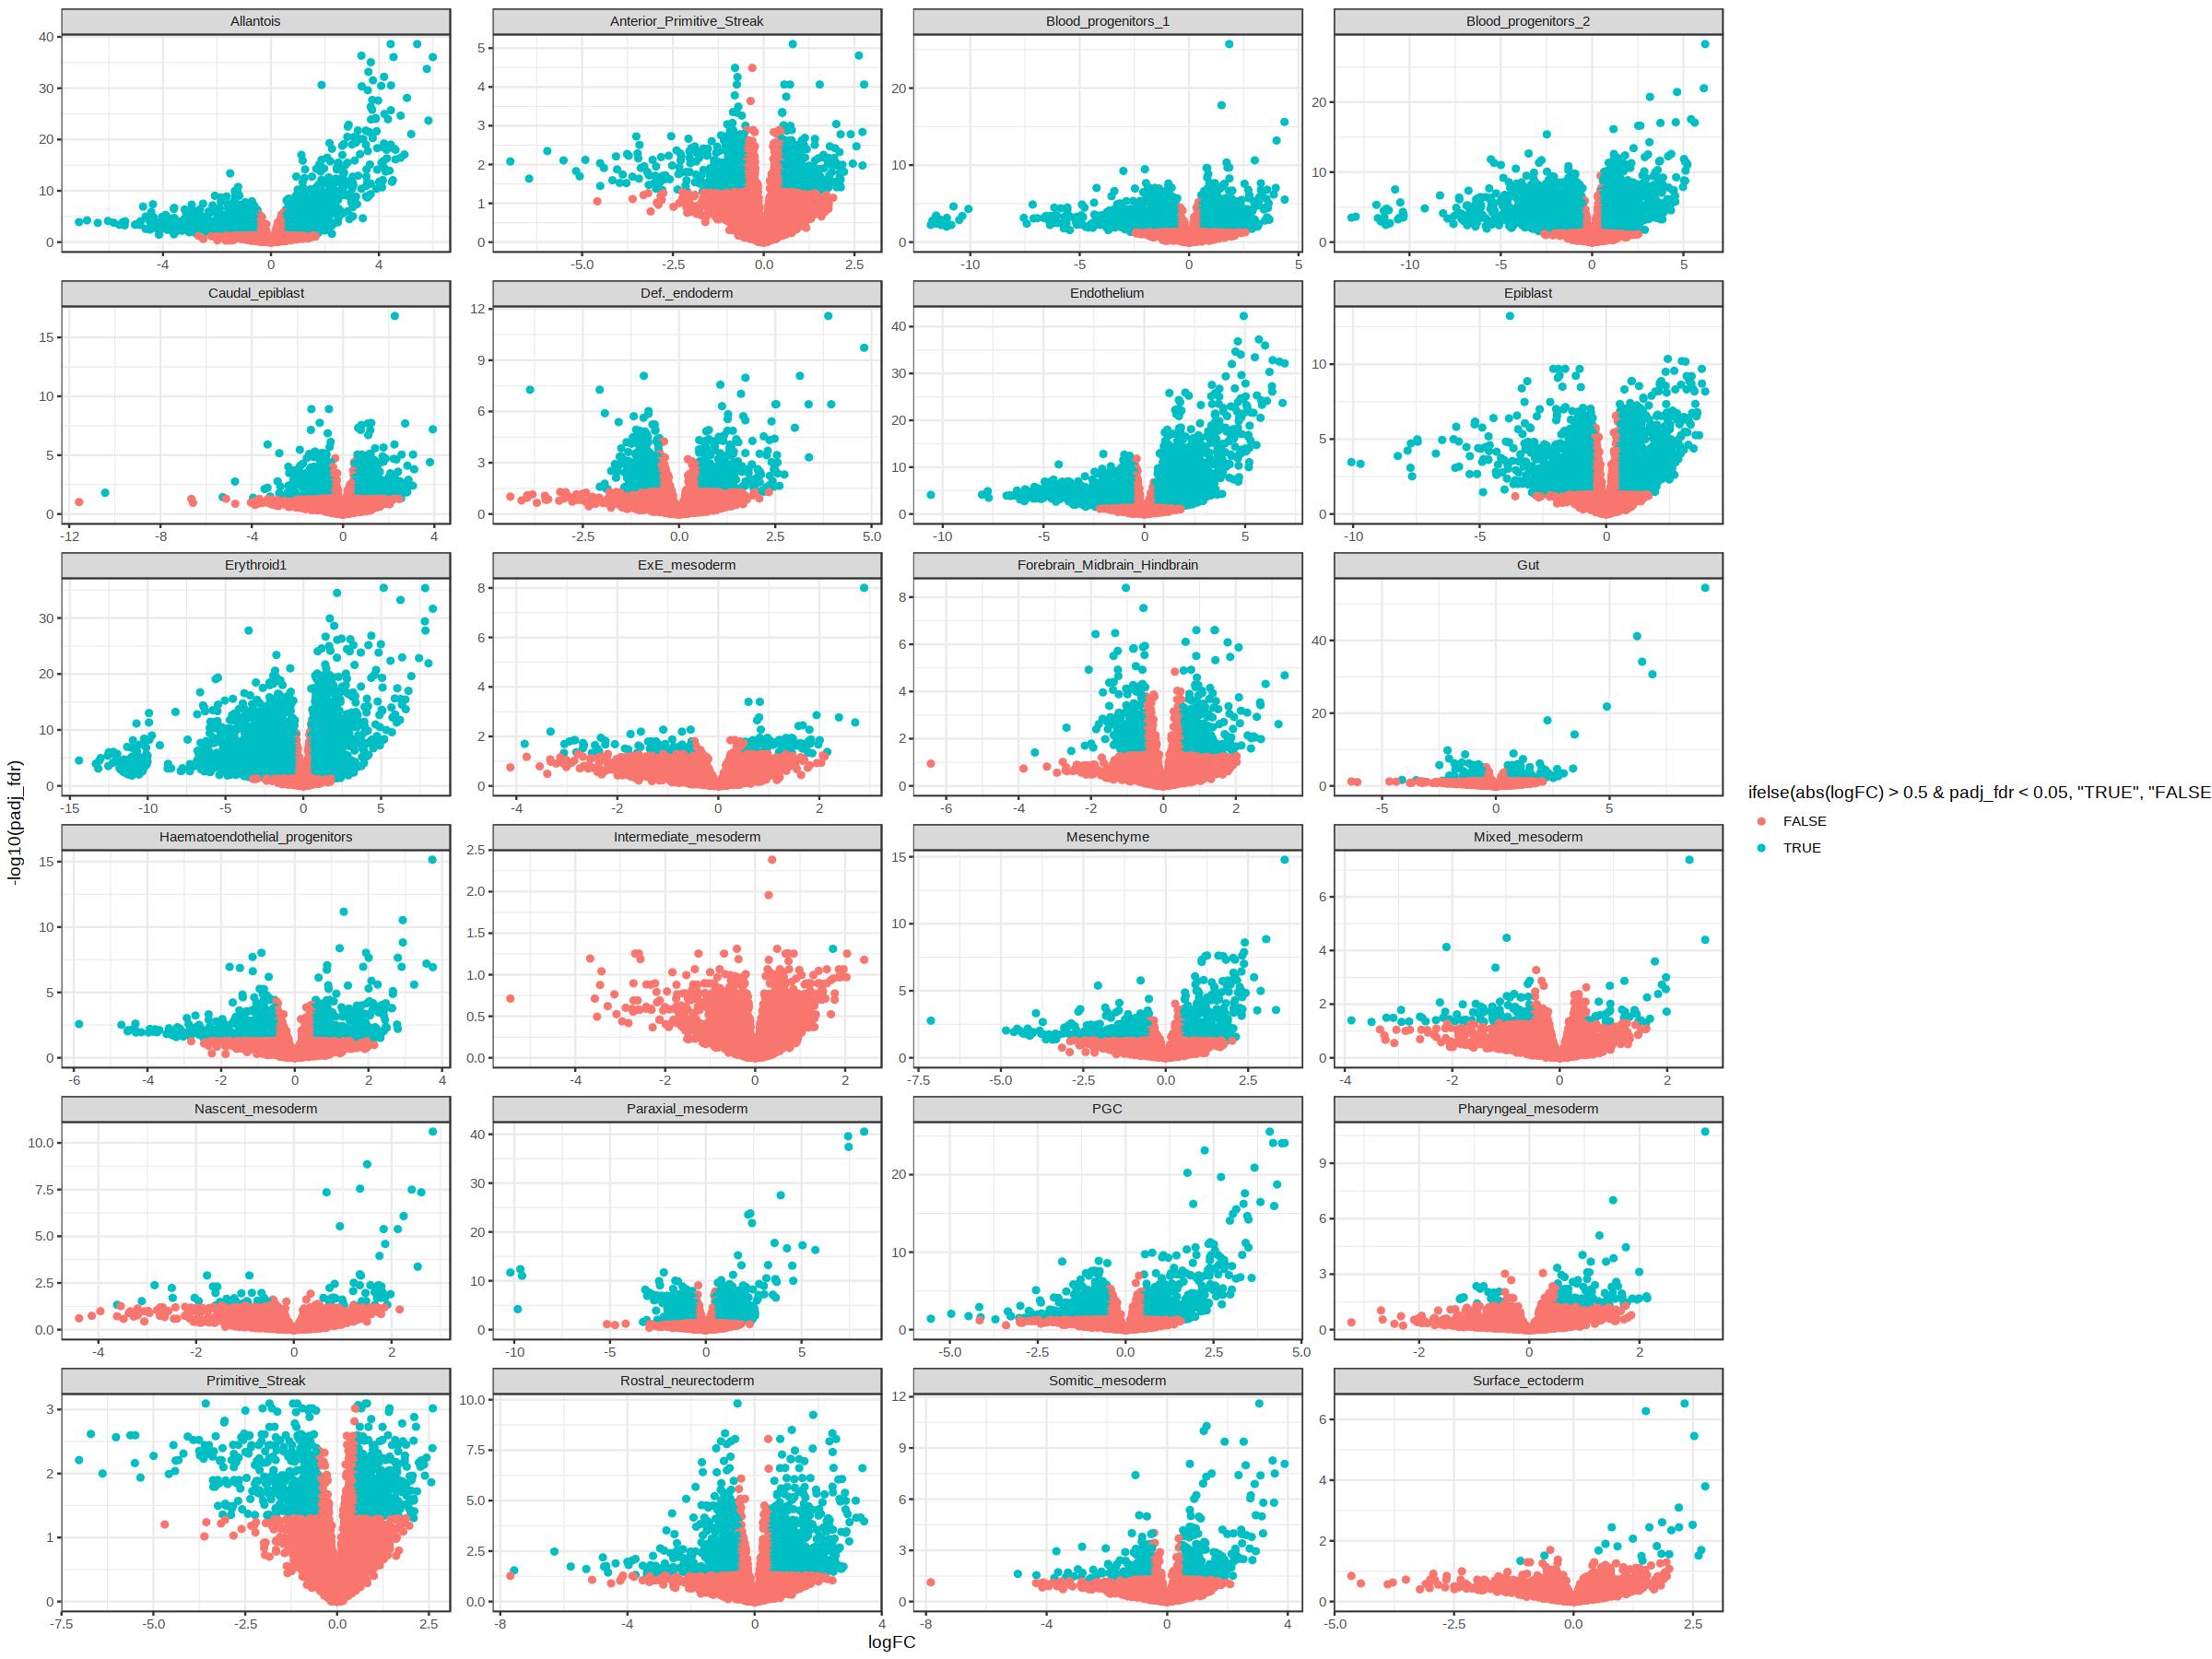

In [78]:
options(repr.plot.width=20, repr.plot.height=15) 

ggplot(DEGs[!is.na(logFC)], aes(logFC, -log10(padj_fdr), col=ifelse(abs(logFC)>0.5 & padj_fdr<0.05, 'TRUE', 'FALSE'))) + 
    geom_point() + 
    facet_wrap(~celltype, ncol = 4, scales='free') + 
    #scale_colour_discrete(values=c('red', 'black')) + 
    theme_bw() 